<a href="https://colab.research.google.com/github/dhanushreddy0726-ops/missingvalues/blob/main/handlingdata.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

     Transaction ID      Item Quantity Price Per Unit Total Spent  \
0       TXN_1961373    Coffee        2            2.0         4.0   
1       TXN_4977031      Cake        4            3.0        12.0   
2       TXN_4271903    Cookie        4            1.0       ERROR   
3       TXN_7034554     Salad        2            5.0        10.0   
4       TXN_3160411    Coffee        2            2.0         4.0   
...             ...       ...      ...            ...         ...   
9995    TXN_7672686    Coffee        2            2.0         4.0   
9996    TXN_9659401       NaN        3            NaN         3.0   
9997    TXN_5255387    Coffee        4            2.0         8.0   
9998    TXN_7695629    Cookie        3            NaN         3.0   
9999    TXN_6170729  Sandwich        3            4.0        12.0   

      Payment Method  Location Transaction Date  
0        Credit Card  Takeaway       2023-09-08  
1               Cash  In-store       2023-05-16  
2        Credit Card 

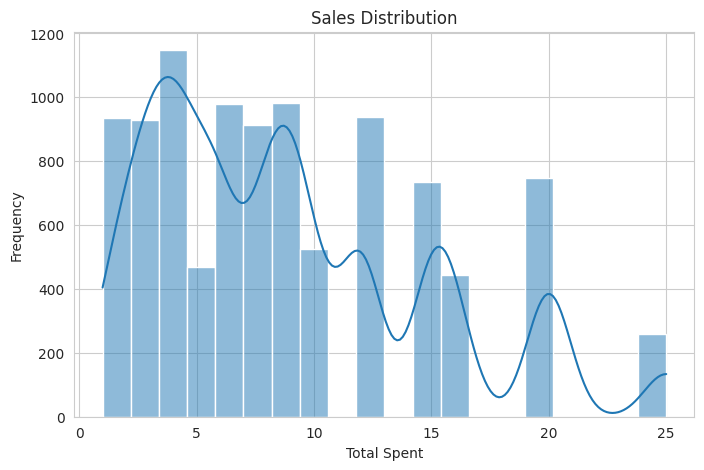

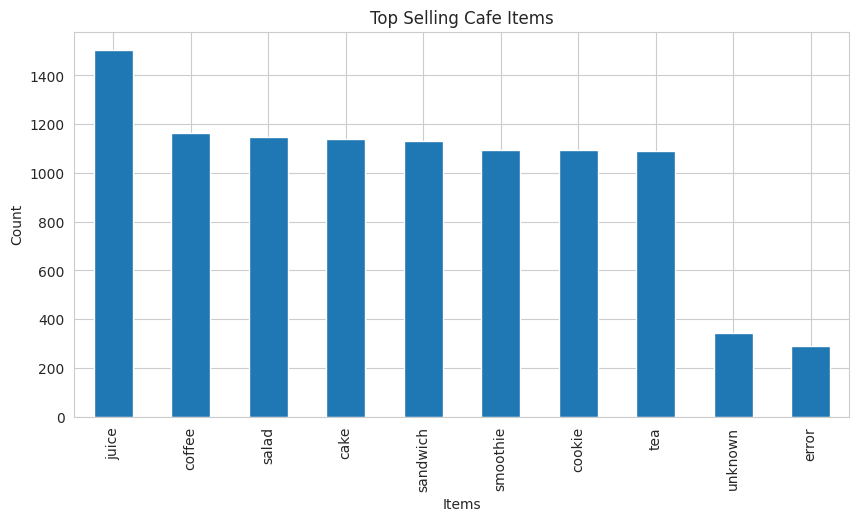

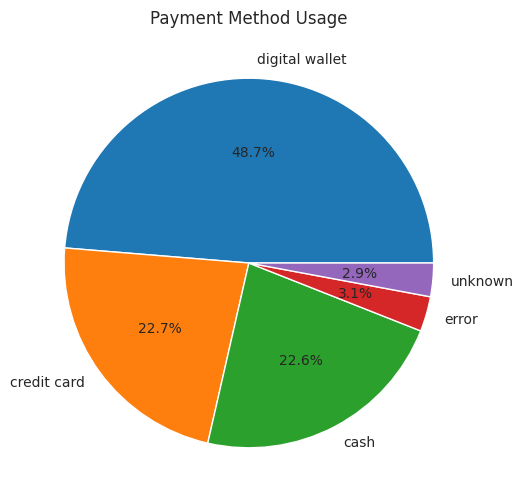

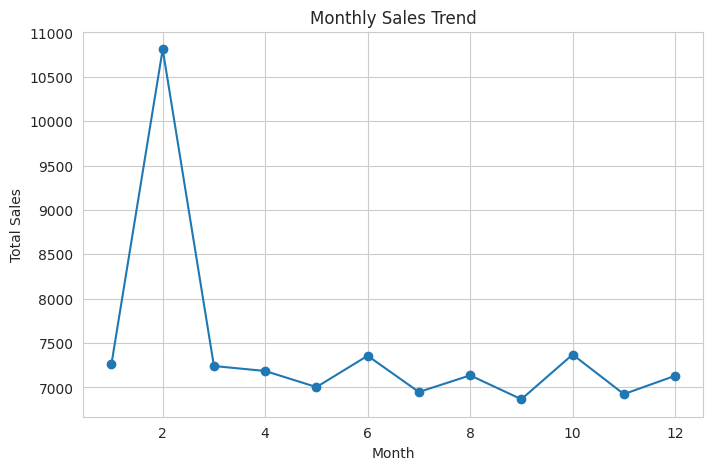

Files Saved Successfully!


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('/content/dirty_cafe_sales.csv')
print(df)
print(df.isnull().sum())
print(df.duplicated().sum())

df = df.drop_duplicates()

df['Item'] = df['Item'].fillna(df['Item'].mode()[0])

df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')
df['Quantity'] = df['Quantity'].fillna(df['Quantity'].mean())

df['Price Per Unit'] = pd.to_numeric(df['Price Per Unit'], errors='coerce')
df['Price Per Unit'] = df['Price Per Unit'].fillna(df['Price Per Unit'].mean())

df['Total Spent'] = pd.to_numeric(df['Total Spent'], errors='coerce')
df['Total Spent'] = df['Total Spent'].fillna(df['Total Spent'].mean())

df['Payment Method'] = df['Payment Method'].fillna(df['Payment Method'].mode()[0])

df['Location'] = df['Location'].fillna(df['Location'].mode()[0])

df['Transaction Date'] = df['Transaction Date'].fillna(df['Transaction Date'].mode()[0])

df['Item'] = df['Item'].str.strip().str.lower()

df['Payment Method'] = df['Payment Method'].str.strip().str.lower()

df['Location'] = df['Location'].str.strip().str.lower()

#df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], errors='coerce')

df['Transaction Date'] = df['Transaction Date'].fillna(df['Transaction Date'].mode()[0])

print(df.isnull().sum())

total_sales = df['Total Spent'].sum()

average_sales = df['Total Spent'].mean()

print("Total Sales:", total_sales)

print("Average Sales:", average_sales)

top_items = df['Item'].value_counts().head(10)

print(top_items)

payment_report = df['Payment Method'].value_counts()

print(payment_report)

monthly_sales = df.groupby(df['Transaction Date'].dt.month)['Total Spent'].sum()

print(monthly_sales)

sns.set_style("whitegrid")

plt.figure(figsize=(8,5))
sns.histplot(df['Total Spent'], bins=20, kde=True)
plt.title("Sales Distribution")
plt.xlabel("Total Spent")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(10,5))
df['Item'].value_counts().head(10).plot(kind='bar')
plt.title("Top Selling Cafe Items")
plt.xlabel("Items")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(6,6))
df['Payment Method'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Payment Method Usage")
plt.ylabel("")
plt.show()

plt.figure(figsize=(8,5))
monthly_sales.plot(marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()

df.to_csv("cleaned_cafe_sales.csv", index=False)

summary = pd.DataFrame({
    "Total Sales": [total_sales],
    "Average Sales": [average_sales],
    "Total Orders": [len(df)]
})

summary.to_csv("cafe_sales_summary.csv", index=False)

print("Files Saved Successfully!")